In [1]:
# Fake News Detector using Machine Learning Models
# Author: Ila Wallace
# Creation Date: 03/19/2025
# Last Updated: 08/21/2025

# This program is a fake news detector that utilizes machine learning 
# to analyze and classify news articles that may be either real or fake.
# The machine learning models used within this program include Naive Bayes, 
# Logistic Regression, Random Forest, and Support Vector Machine. To support 
# the models, TfidfVectorizer, KMeans, and RandomForestClassifier are used 
# to present the information in a usable way for some models and for others 
# to highlight the key features the models should consider as important 
# features. It also uses a simple function for preprocessing the plain text 
# data of the news articles in order to filter out unnecessary characters 
# and to make sure the text will be accepted by the models during the training 
# and testing phases. The two relevant files are named "fake_news.csv" and 
# "true_news.csv". 

# Note: Do not run this cell. This is just for documentation purposes.

In [2]:
# Imports all the related libraries required for this python project to run correctly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # sometimes, the matplotlib library requires more time to load for its fonts, but it will compile
import re as regex
import time as clock
from pathlib import Path
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.cluster import KMeans as km
from sklearn.ensemble import RandomForestClassifier as rf
from sklearn.naive_bayes import MultinomialNB as nb
from sklearn.linear_model import LogisticRegression as lr
from sklearn.svm import LinearSVC as lsvm
from sklearn.tree import DecisionTreeClassifier as dt

# Prints out that the libraries and tools task is completed
print("The libraries and tools are ready for use.")

# Note: In order for this cell to run correctly, you must have all the libraries 
# listed above installed on your device or you must upload the files into Jupyter 
# Notebook. If any of the libraries listed above are not installed on your computer, 
# open the terminal or command prompt and use the 'pip install' command. 

# Ex. To install pandas, run the following command in your terminal:
# pip install pandas

Matplotlib is building the font cache; this may take a moment.


The libraries and tools are ready for use.


In [3]:
# Array containing words that will be ignored during pre-processing of the text data
stop_words = { "a", "an", "are", "as", "and", "at", "but", "be", "by",
              "been", "for", "from", "had", "have", "has", "he", "her", 
              "his", "i", "if", "in", "is", "it", "its", "me", "my", "no", 
              "not", "of", "on", "or", "our", "she", "so", "some", "such", 
              "that", "the", "their", "them", "then", "there", "these", 
              "they", "this", "themselves", "those", "to", "too", "us", 
              "we", "were", "what", "with", "which", "will", "would",
              "you", "your", "yours", "yourself", "yourselves" }

# This function pre-processes the data found in the given datasets to not consider 
# common "stop words," meaning the words that don't actually add any real meaning 
# to the plain text, but are still necessary for the other words to convey the 
# meaning of a sentence or follow proper grammar rules.
def preprocess_plain_text(news_text):
    if pd.isna(news_text): # checks for missing values (na) and replaces them with ""
        return ""
    news_text = news_text.lower()
    news_text = regex.sub(r'[^\w\s]', '', news_text) # replaces unwanted characters with ''
    news_text = regex.sub(r'\d+', '', news_text) # replaces unwanted characters with ''
    plain_text = news_text.split() 
    plain_text = [word for word in plain_text if word not in stop_words] # removes stop_words that exist in the plain text
    return ' '.join(plain_text)

# This function balances the data found in the given datasets by determining which 
# dataset has the least amount of data present in it and then resampling the data 
# of the larger dataset to match.
def balance_datasets(true_news_df, fake_news_df):
    min_dataset_size = min(len(true_news_df), len(fake_news_df))
    true_news_balanced_df = resample(true_news_df, replace=False, n_samples=min_dataset_size, random_state=42)
    fake_news_balanced_df = resample(fake_news_df, replace=False, n_samples=min_dataset_size, random_state=42)
    return true_news_balanced_df, fake_news_balanced_df

In [4]:
# Identifies the current directory path
dataset_path = Path().resolve() / 'datasets'

# Reads the datasets from their respective .csv files for the models to use
true_news_df = pd.read_csv(dataset_path / 'true-news.csv', encoding='utf-8', on_bad_lines='skip', engine='python') # your path to the dataset must be './true-news.csv' or it will not work
fake_news_df = pd.read_csv(dataset_path / 'fake-news.csv', encoding='utf-8', on_bad_lines='skip', engine='python') # your path to the dataset must be './fake-news.csv' or it will not work

# Number labels for the two datasets
true_news_df['label'] = 1
fake_news_df['label'] = 0

# Text labels for the two datasets
axes = ['Fake News', 'Real News']

# Balances the datasets if counts are skewed towards one dataset over the other
true_news_df, fake_news_df = balance_datasets(true_news_df, fake_news_df)

# Combines the two datasets into one dataset 'news_df'
news_df = pd.concat([true_news_df, fake_news_df], ignore_index=True)

# Preprocesses the text data in the combined dataset 'news_df' using preprocess_plain_text()
news_df["text"] = news_df["text"].fillna('').apply(preprocess_plain_text)

# Prints out that the preprocessing task is completed
print("Data preprocessing completed!\n")

# Prints out the number of fake vs. real news articles in the combined dataset news_df
print(news_df["label"].value_counts())

# Prints out the first 5 rows of the dataset (head)
print(news_df.head()) 

Data preprocessing completed!

label
1    21417
0    21417
Name: count, dtype: int64
                                               title  \
0  Europe rights watchdog says Turkey's emergency...   
1  Exclusive: Trump targets illegal immigrants wh...   
2  At G20 summit, Trump pledges $639 million in a...   
3  Ex-Christie associates lose bid for new trial ...   
4  Young blacks more open to Bernie Sanders' Whit...   

                                                text       subject  \
0  brussels reuters leading european rights watch...     worldnews   
1  reuters september gilberto velasquez yearold h...  politicsNews   
2  hamburg reuters president donald trump saturda...  politicsNews   
3  new york reuters federal judge rejected reques...  politicsNews   
4  orangeburg sc reuters democratic hopeful berni...  politicsNews   

                 date  label  
0    October 6, 2017       1  
1       June 9, 2017       1  
2       July 8, 2017       1  
3      March 2, 2017       1  
4 

In [6]:
# Spliting the data into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(news_df['text'], news_df['label'], test_size=0.2, random_state=42, stratify=news_df['label'])

# Printing out that the data splitting task has been completed
print("\nTraining and testing data split completed!\n")

# Printing out some sample data of the training and testing sets
print("\nSample training data:\n", x_train.head())
print("\nSample testing data:\n", x_test.head())

# Printing out some sample labels of the training and testing sets
print("\nSample training labels:\n", y_train.head())
print("\nSample testing labels:\n", y_test.head())


Training and testing data split completed!


Sample training data:
 1009     ljubljana reuters slovenian president borut pa...
29445    speech delivered president ronald reagan memor...
20907    zurich reuters united states consular office s...
34620                                                     
18075    reuters basement third floor democratic party ...
Name: text, dtype: object

Sample testing data:
 16245    mainz germany reuters germany s sept national ...
22078    dozens supporters president donald trump ralli...
3514     istanbul reuters recent developments syria s r...
14863    washington reuters president donald trumps wee...
19207    buenos aires reuters argentina s previous gove...
Name: text, dtype: object

Sample training labels:
 1009     1
29445    0
20907    1
34620    0
18075    1
Name: label, dtype: int64

Sample testing labels:
 16245    1
22078    0
3514     1
14863    1
19207    1
Name: label, dtype: int64


In [7]:
# Vectorizing the plain text data and indentifying the important features
vectorize = TfidfVectorizer(max_features=1000, stop_words='english')
x_train_vector = vectorize.fit_transform(x_train.astype(str))
x_test_vector = vectorize.transform(x_test.astype(str))

# Printing out that the vectorization task is completed
print("\nVectorization completed!\n")

# Using Random Forest to identify the important features (top 200)
rainforest = rf(n_estimators=100, random_state=42)
rainforest.fit(x_train_vector, y_train)
features = rainforest.feature_importances_
indexes = np.argsort(features)[-200:]
best_features = vectorize.get_feature_names_out()[indexes]
x_top = x_train_vector[:, indexes]

# Printing out that the features task is completed
print("Feature importance calculated!\n") 

# Prints out the best features (top 200)
print("Top 200 features:\n", best_features)

# Clustering the data using KMeans
meank = km(n_clusters=5, random_state=42, n_init=10)
x_cluster = meank.fit_predict(x_top)

# Printing out that the clustering task is completed
print("\nClustering completed!\n") 


Vectorization completed!

Feature importance calculated!

Top 200 features:
 ['political' 'good' 'saying' 'parties' 'congress' 'added' 'police'
 'agreed' 'room' 'day' 'spokeswoman' 'confirmed' 'federal' 'john' 'senior'
 'adding' 'appears' 'say' 'nation' 'campaign' 'referendum' 'person'
 'london' 'killed' 'following' 'city' 'live' 'doing' 'court' 'country'
 'years' 'left' 'morning' 'isis' 'think' 'national' 'does' 'according'
 'truth' 'south' 'post' 'expressed' 'statements' 'beijing' 'make' 'guy'
 'legislation' 'county' 'barack' 'billion' 'senator' 'want' 'host' 'lives'
 'leaders' 'saturday' 'election' 'apparently' 'media' 'times' 'coalition'
 'great' 'fbi' 'reported' 'official' 'authorities' 'press' 'party'
 'declined' 'new' 'earlier' 'mr' 'white' 'woman' 'committee' 'economic'
 'sunday' 'korea' 'cnn' 'week' 'racist' 'north' 'realdonaldtrump' 'hate'
 'pretty' 'things' 'union' 'opposition' 'night' 'people' 'today' 'says'
 'americans' 'going' 'presidential' 'eu' 'britain' 'obamas' 'dail

In [8]:
# This function evalutates a given model and prints out its performance metrics
def evaluate_model(name, model):
    # Tests and trains the given model
    model.fit(x_train_vector, y_train)
    y_predict = model.predict(x_test_vector)

    # Calculates the accuracy of the model for the testing/training data, 
    # generate the classification report, the cross validation score, 
    # the confusion matrix, and the learning curve values for display
    test_accuracy = accuracy_score(y_test, y_predict)
    train_accuracy = accuracy_score(y_train, model.predict(x_train_vector))
    class_report = classification_report(y_test, y_predict)
    cv_score = cross_val_score(model, x_train_vector, y_train, cv=5)
    cm = confusion_matrix(y_test, y_predict, labels=[0, 1])
    train_sizes, train_scores, test_scores = learning_curve(model, x_train_vector, y_train, cv=5)

    # Prints out the performance metrics for the given model
    print(f"\n{name} Performance Metrics:\n")
    print(f"Testing Accuracy: {test_accuracy}")
    print(f"Training Accuracy: {train_accuracy}")
    print(f"Cross-Validation Mean Accuracy: {cv_score.mean()} +/- {cv_score.std()}\n")
    print(f"{class_report}\n")

    # Displays the confusion matrix 
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=axes)
    cm_display.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    print("\n") # spacing out the output
    
    # Displays the learning curve graph
    plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Testing Score')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy Score')
    plt.title(f'Learning Curve for {name}')
    plt.legend()
    plt.show()


Naive Bayes Performance Metrics:

Testing Accuracy: 0.9314194577352473
Training Accuracy: 0.9276505250099686
Cross-Validation Mean Accuracy: 0.9294661864086187 +/- 0.009567533644759554

              precision    recall  f1-score   support

           0       0.97      0.89      0.93      2822
           1       0.90      0.97      0.93      2821

    accuracy                           0.93      5643
   macro avg       0.93      0.93      0.93      5643
weighted avg       0.93      0.93      0.93      5643




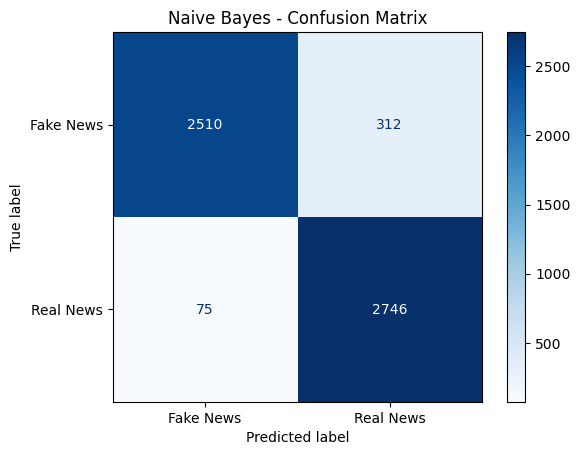

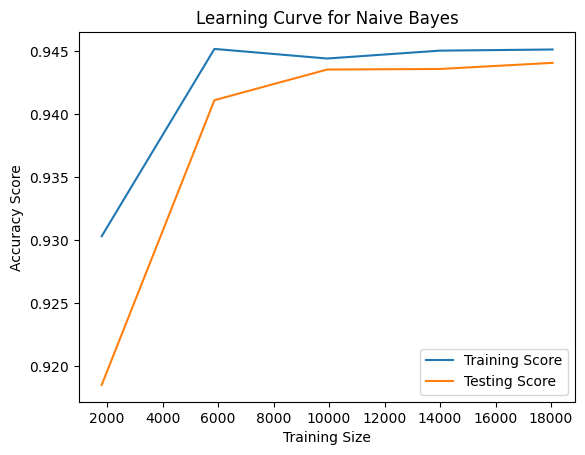


Execution time: 0.623999834060669 seconds


In [8]:
# Start the stopwatch
start_time = clock.time()

# Initialize and evaluate the Naive Bayes model
navy_bay = nb()
evaluate_model("Naive Bayes", navy_bay)

# Stop the stopwatch
end_time = clock.time()

# Calculate the execution time of the model
execution_time = end_time - start_time

# Print out the total execution time of the model
print(f"\nExecution time: {execution_time} seconds")


Logistic Regression Performance Metrics:

Testing Accuracy: 0.9758375160499592
Training Accuracy: 0.9770624799369656
Cross-Validation Mean Accuracy: 0.9739107271288923 +/- 0.0007970810573056413

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      4284
           1       0.97      0.98      0.98      4283

    accuracy                           0.98      8567
   macro avg       0.98      0.98      0.98      8567
weighted avg       0.98      0.98      0.98      8567




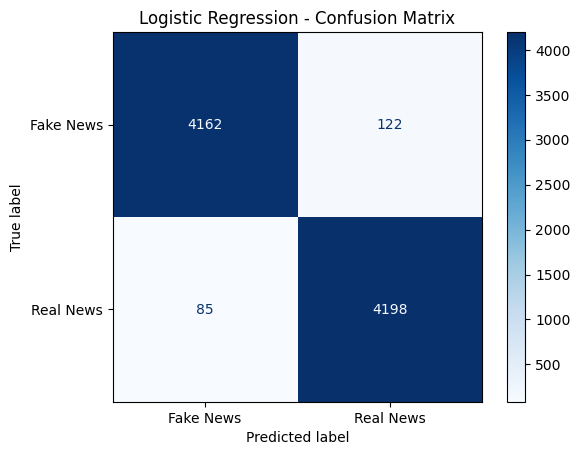

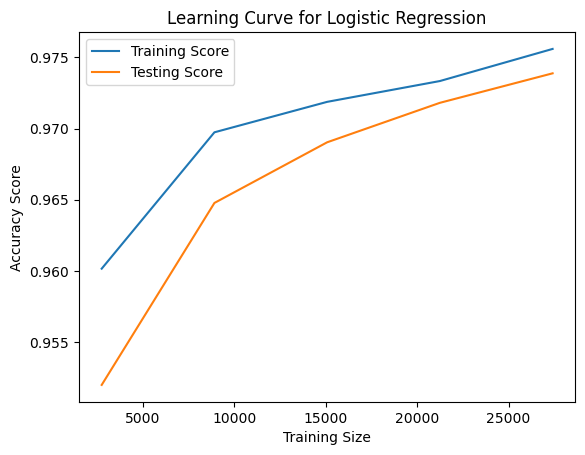


Execution time: 2.0880000591278076 seconds


In [9]:
# Start the stopwatch
start_time = clock.time()

# Initialize and evaluate the Logistic Regression model
logger = lr(max_iter=1000, solver='liblinear', C=0.1)
evaluate_model("Logistic Regression", logger)

# Stop the stopwatch
end_time = clock.time()

# Calculate the execution time of the model
execution_time = end_time - start_time

# Print out the total execution time of the model
print(f"\nExecution time: {execution_time} seconds")


Support Vector Machine Performance Metrics:

Testing Accuracy: 0.994513832146609
Training Accuracy: 0.9968482796859953
Cross-Validation Mean Accuracy: 0.9927627154274106 +/- 0.00023710907848043753

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4284
           1       0.99      1.00      0.99      4283

    accuracy                           0.99      8567
   macro avg       0.99      0.99      0.99      8567
weighted avg       0.99      0.99      0.99      8567




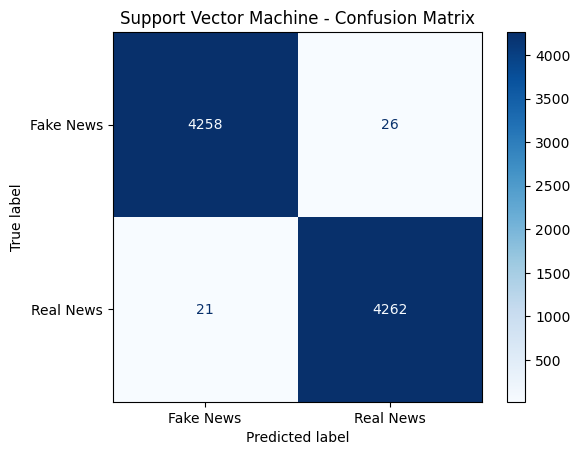

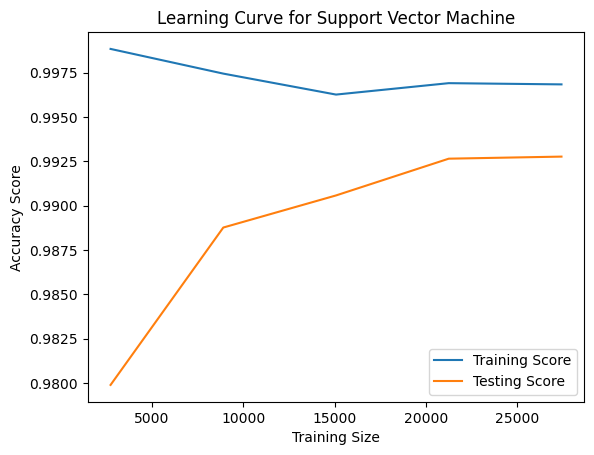


Execution time: 2.5279998779296875 seconds


In [10]:
# Start the stopwatch
start_time = clock.time()

# Initialize and evaluate the Support Vector Machine (SVM) model
supportor = lsvm(C=1, max_iter=1000)
evaluate_model("Support Vector Machine", supportor)

# Stop the stopwatch
end_time = clock.time()

# Calculate the execution time of the model
execution_time = end_time - start_time

# Print out the total execution time of the model
print(f"\nExecution time: {execution_time} seconds")


Decision Tree Performance Metrics:

Testing Accuracy: 0.9954476479514416
Training Accuracy: 0.995330784719993
Cross-Validation Mean Accuracy: 0.9937258015473638 +/- 0.000958619740284198

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4284
           1       0.99      1.00      1.00      4283

    accuracy                           1.00      8567
   macro avg       1.00      1.00      1.00      8567
weighted avg       1.00      1.00      1.00      8567




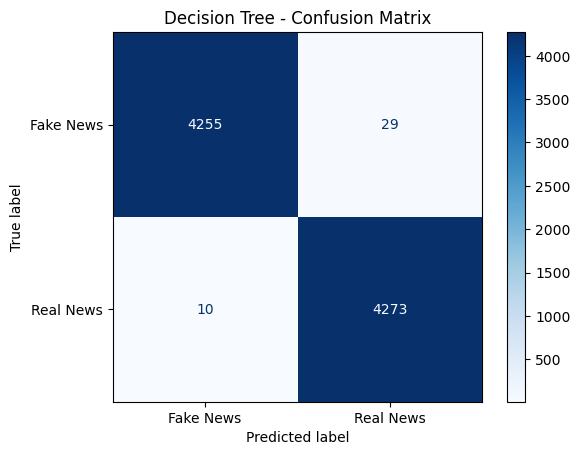

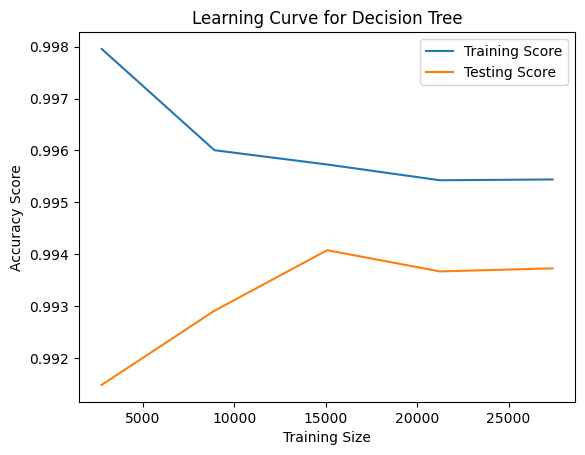


Execution time: 22.043999910354614 seconds


In [11]:
# Start the stopwatch
start_time = clock.time()

# Initialize and evaluate the Decision Tree model
dectree = dt(max_depth=5, random_state=42)
evaluate_model("Decision Tree", dectree)

# Stop the stopwatch
end_time = clock.time()

# Calculate the execution time of the model
execution_time = end_time - start_time

# Print out the total execution time of the model
print(f"\nExecution time: {execution_time} seconds")